In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Load data and remove downtime

The provided data includes timestamps where 'Well_down' == True ('VSD power frequency' < 7). We remove these rows from the data to reduce memory usage, as their values are not passed to the pipeline.

In [2]:
data_hour = pd.read_csv('dados equinor - teams/full_sensor_1h [old].csv')
data_hour.index = pd.to_datetime(data_hour.index)

data_hour.drop(data_hour[data_hour['Well_down']==1].index,inplace=True)
data_hour.drop(['Well_down'],axis=1,inplace=True)

data_hour.to_csv("hour_data_run.csv",index=False)


In [3]:
data_min = pd.read_csv('dados equinor - teams/full_sensor_1min_resampled_V2 [old].csv')
data_min.index = pd.to_datetime(data_min.index)

data_min.drop(data_min[data_min['Well_down']==1].index,inplace=True)
data_min.drop(['Well_down'],axis=1,inplace=True)

data_min.to_csv("min_data_run.csv",index=False)


In [4]:
data_full = pd.merge(data_hour,data_min,on=['time','Well Run'],how='outer')

del(data_min)
del(data_hour)

In [5]:
data_full.to_csv("merged_data.csv",index=False)

This file "merged_data.csv" has the non treated data (with NAs)

# Data interpolation and day difference features

Load data if not loaded

In [341]:
data_full = pd.read_csv("merged_data.csv")
data_full.set_index('time',inplace=True)
data_full.index = pd.to_datetime(data_full.index)
data_full.head(3)

,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,ESP discharge pressure,...,extValues_ESP discharge pressure,extValues_ESP discharge temperature sensor,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature
time,,,,,,,,,,,,,,,,,,,,,
2011-12-26 21:00:00+00:00,63.0,66.94,64.0,40.08,NaN,118.51,147.69,0.7,77.48,229.39,...,60.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 22:00:00+00:00,64.0,67.00,64.0,39.99,NaN,116.11,144.47,0.7,78.37,224.55,...,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-12-26 23:00:00+00:00,64.0,67.00,64.0,40.08,NaN,114.61,142.83,0.7,78.58,221.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


To interpolate the data and generate the appropriate statistical features that are to be tested, we must separate the data from each well and then create these new columns. Statistical data include historical average, median and exponential moving averages.

In [342]:
# Setting up historical averages to be calculated (0 means all days)
failure_days = [30,60,100]
long_run_days = [1000]

# Creating additional columns
columns = ['Date Difference', 'Cumulative Downtime', 'Total Runtime']

columns.extend([f'Failure {day} days' for day in failure_days])
columns.extend([f'Long Run {day} days' for day in long_run_days])

columns

['Date Difference',
 'Cumulative Downtime',
 'Total Runtime',
 'Failure 30 days',
 'Failure 60 days',
 'Failure 100 days',
 'Long Run 1000 days']

In [343]:
# Getting well ids


data_full[columns] = np.nan
well_ids = np.unique(data_full['Well Run'])

new_dataframes = [None]*well_ids.size

for i,id in enumerate(well_ids):

    # Getting data from well
    ind = data_full['Well Run'] == id
    well_data = data_full[ind].copy()
   # data_full[ind]
    
    # Interpolating data
    well_data.sort_values('time',inplace=True)
    well_data.interpolate(method='linear', limit_area='inside',inplace=True)
    
    
    # Calculating cumulative downtime of well
    time_difference = well_data.index.diff() 
    downtime_hours  = (time_difference - datetime.timedelta(hours=1))/datetime.timedelta(days=1)
    cumulative_downtime = pd.DataFrame(downtime_hours).cummax()
    well_data['Cumulative Downtime'] = cumulative_downtime.to_numpy()

    # Writing runtime and date difference
    runtime = np.linspace(0,well_data.shape[0]/24.,well_data.shape[0])
    date_difference = (well_data.index-well_data.index.min())/datetime.timedelta(days=1) 
    well_data['Total Runtime'] = runtime
    well_data['Date Difference'] = date_difference.to_numpy()

    # Writing failure and long run
    max_runtime = runtime.max()
    for day in failure_days:
        ind_col = f'Failure {day} days'
        well_data[ind_col] = runtime >= max_runtime - day

    for day in long_run_days:
        ind_col = f'Long Run {day} days'
        well_data[ind_col] = date_difference <= max_runtime - day

    new_dataframes[i] = well_data

data_full = pd.concat(new_dataframes)


In [344]:
np.unique(data_full['Well Run'])

array(['A-03 1', 'A-03 2', 'A-04 1', 'A-06 1', 'A-06 2', 'A-08 1',
       'A-08 2', 'A-09 1', 'A-09 2', 'A-10 1', 'A-12 1', 'A-12 2',
       'A-15 1', 'A-17 1', 'A-18 1', 'A-18 2', 'A-21 1', 'A-21 2',
       'A-22 1', 'A-22 2', 'A-22 3', 'A-23 1', 'A-24 1', 'A-24 2',
       'A-27 1', 'A-28 1', 'A-29 1', 'A-29 2', 'B-01 1', 'B-02 1',
       'B-03 1', 'B-04 1', 'B-04 2', 'B-04 3', 'B-05 1', 'B-07 2',
       'B-08 3', 'B-09 1', 'B-10 1', 'B-13 1', 'B-14 1', 'B-16 1',
       'B-16 2', 'B-17 1', 'B-18 1', 'B-18 2', 'B-18 3', 'B-19 1',
       'B-21 1', 'B-22 1', 'B-22 2', 'B-22 3', 'B-22 4', 'B-23 1',
       'B-23 2', 'B-23 3', 'B-26 1', 'B-27 1', 'B-30A 1'], dtype=object)

In [349]:
data_full.index = pd.to_datetime(data_full.index)

# Setting up historical averages to be calculated

def get_statistical_data(data_full, column, stat_type, days):

    if stat_type not in ["Average", "Median", "Exponential"]:
        raise ValueError("Invalid statistical data type!")

    if column not in data_full:
        raise ValueError("Invalid column name!")

    if days == 0:
        data_name = f'{stat_type} all days'
    else:
        data_name = f'{stat_type} {days} days'

    time_diff = datetime.timedelta(days=days)
    new_data = pd.Series(data=data_full[column].copy(),index=data_full.index,dtype=float,name=data_name)
    well_ids = np.unique(data_full['Well Run'])
    
    if stat_type == "Average":
        if days == 0:
            for id in well_ids:
                
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].expanding().mean()
        else:
            for id in well_ids:
                
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].rolling(time_diff,min_periods=1).mean()
                
    elif stat_type == "Median":
        if days == 0:
            for id in well_ids:
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].expanding().median()
        else:
            for id in well_ids:
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].rolling(time_diff,min_periods=1).median()
                
    elif stat_type == "Exponential":
        if days == 0:
            for id in well_ids:
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].ewm().mean()
        else:
            for id in well_ids:
                ind = data_full['Well Run'] == id
                new_data[ind] = new_data[ind].ewm(halflife=time_diff).mean()

    return new_data


In [212]:
data_full['100 days failure'] = get_failure(data_full,100)
data_full['60 days failure'] = get_failure(data_full,60)
data_full['1000 days run'] = get_failure(data_full,1000,is_failure=False)

data_full.head(3)

,100 days failure,ESP motor Current - phase A,ESP motor Current - phase B,ESP motor Current - phase C,VSD power frequency,ESP motor temperature,ESP differential pressure,ESP intake Pressure,Water Cut @ 20degC/1 atm,ESP intake temperature,...,extValues_Choke Opening,extValues_Well head pressure,extValues_Well aligned to Train A,extValues_Well aligned to Train B,extValues_ESP Motor Voltage,extValues_ESP Vibration X,extValues_ESP Vibration Y,extValues_Well head Temperature,1000 days run,60 days failure
time,,,,,,,,,,,,,,,,,,,,,
2011-12-26 21:00:00+00:00,False,63.0,66.94,64.0,40.08,NaN,118.51,147.69,0.7,77.48,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
2011-12-26 22:00:00+00:00,False,64.0,67.00,64.0,39.99,NaN,116.11,144.47,0.7,78.37,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False
2011-12-26 23:00:00+00:00,False,64.0,67.00,64.0,40.08,NaN,114.61,142.83,0.7,78.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False


In [49]:
data_full.to_csv("merged_data.csv")

Alguns poços já começaram a operação dentro de seus 100 dias de operação antes da falha, estes são:

'A-03 2', 'A-06 1', 'A-12 1', 'A-15 1', 'B-01 1', 'B-04 2',
       'B-23 1', 'B-26 1'

# Selecting features

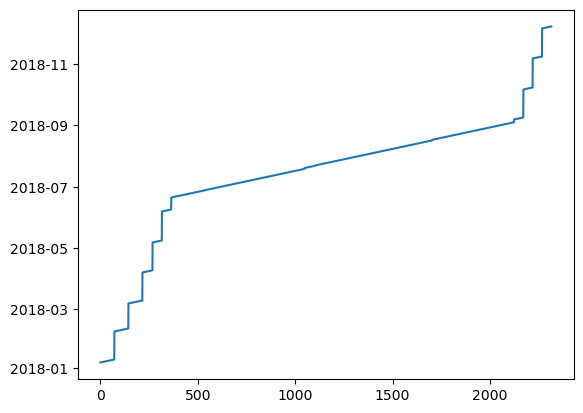

In [346]:
ind = data_full['Well Run'] == 'A-06 1'
plt.plot(data_full[ind].index)

In [370]:
a = data_full['VSD power frequency'].dtypes
print(a=='float64')

True


In [347]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(mutual_info_classif, k='all')
y = data_full['Failure 100 days'].astype('bool')

In [350]:
columns = data_full.columns



for column in columns
    column = 'VSD power frequency'
    stat_type = 'Average'
    days = 3
    av_VSD = get_statistical_data(data_full, column, stat_type, days)
    
    av_VSD = av_VSD < 47.996

In [376]:
data_full['VSD power frequency'].mean()

57.28790826682098

In [351]:
x_new = selector.fit(av_VSD.values.reshape(-1, 1),y)
scores=selector.scores_

In [352]:
a = scores
print(scores)

[0.01305382]


In [353]:
column = 'ESP Vibration X'
stat_type = 'Average'
days = 15
av_VibX = get_statistical_data(data_full, column, stat_type, days)

av_VibX = av_VibX > 0.085

In [354]:
x_new = selector.fit(av_VibX.values.reshape(-1, 1),y)
scores=selector.scores_

In [355]:
b = scores
print(scores)

[0.15701321]


In [356]:
column = 'peaks_ESP motor temperature'
stat_type = 'Average'
days = 31
av_Peak = get_statistical_data(data_full, column, stat_type, days)

av_Peak = av_Peak < 2.751

In [357]:
x_new = selector.fit(av_Peak.values.reshape(-1, 1),y)
scores=selector.scores_

In [358]:
c = scores
print(scores)

[0.01139205]


In [359]:
print(a,b,c)

[0.01305382] [0.15701321] [0.01139205]


In [363]:
v = np.array([a,b,c])
print(v/v[1]*0.04)

[[0.00332553]
 [0.04      ]
 [0.00290219]]


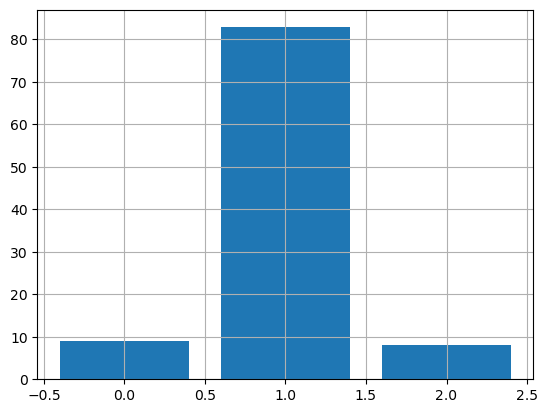

In [361]:
n1 = np.sum(data_full['Long Run 1000 days'])
n2 = np.sum((data_full['Failure 60 days'] == False) & data_full['Long Run 1000 days'] == False )
n3 = np.sum(data_full['Failure 60 days'])
#a = data_full['1000 days run'].value_counts()

pct = np.array([n1,n2,n3])/(n1+n2+n3)*100
plt.bar([0,1,2],pct)
plt.grid()


In [262]:
a = data_full['ESP Vibration X']

a.diff().abs()
b = a.resample('w').max()
b

time
2011-04-10 00:00:00+00:00    0.00
2011-04-17 00:00:00+00:00    0.00
2011-04-24 00:00:00+00:00    1.04
2011-05-01 00:00:00+00:00    2.06
2011-05-08 00:00:00+00:00    2.72
                             ... 
2020-11-08 00:00:00+00:00     NaN
2020-11-15 00:00:00+00:00     NaN
2020-11-22 00:00:00+00:00     NaN
2020-11-29 00:00:00+00:00     NaN
2020-12-06 00:00:00+00:00     NaN
Freq: W-SUN, Name: ESP Vibration X, Length: 505, dtype: float64

In [280]:
data_full['ESP differential pressure'].ewm(span=10).mean().iloc[:10]

time
2011-12-26 21:00:00+00:00    118.510000
2011-12-26 22:00:00+00:00    117.190000
2011-12-26 23:00:00+00:00    116.152857
2011-12-27 00:00:00+00:00    115.150371
2011-12-27 01:00:00+00:00    104.166859
2011-12-27 02:00:00+00:00     96.705502
2011-12-27 05:00:00+00:00    103.800443
2011-12-27 06:00:00+00:00    108.668945
2011-12-27 07:00:00+00:00    112.193728
2011-12-27 08:00:00+00:00    114.770334
Name: ESP differential pressure, dtype: float64

In [277]:
data_full['ESP differential pressure'].iloc[:10]

time
2011-12-26 21:00:00+00:00    118.51
2011-12-26 22:00:00+00:00    116.11
2011-12-26 23:00:00+00:00    114.61
2011-12-27 00:00:00+00:00    113.11
2011-12-27 01:00:00+00:00     76.89
2011-12-27 02:00:00+00:00     75.44
2011-12-27 05:00:00+00:00    126.15
2011-12-27 06:00:00+00:00    125.20
2011-12-27 07:00:00+00:00    124.87
2011-12-27 08:00:00+00:00    124.46
Name: ESP differential pressure, dtype: float64

In [281]:
well_ids

array(['A-03 1', 'A-03 2', 'A-04 1', 'A-06 1', 'A-06 2', 'A-08 1',
       'A-08 2', 'A-09 1', 'A-09 2', 'A-10 1', 'A-12 1', 'A-12 2',
       'A-15 1', 'A-17 1', 'A-18 1', 'A-18 2', 'A-21 1', 'A-21 2',
       'A-22 1', 'A-22 2', 'A-22 3', 'A-23 1', 'A-24 1', 'A-24 2',
       'A-27 1', 'A-28 1', 'A-29 1', 'A-29 2', 'B-01 1', 'B-02 1',
       'B-03 1', 'B-04 1', 'B-04 2', 'B-04 3', 'B-05 1', 'B-07 2',
       'B-08 3', 'B-09 1', 'B-10 1', 'B-13 1', 'B-14 1', 'B-16 1',
       'B-16 2', 'B-17 1', 'B-18 1', 'B-18 2', 'B-18 3', 'B-19 1',
       'B-21 1', 'B-22 1', 'B-22 2', 'B-22 3', 'B-22 4', 'B-23 1',
       'B-23 2', 'B-23 3', 'B-26 1', 'B-27 1', 'B-30A 1'], dtype=object)